# Project 1: AI vs. Human Text Detection
### CS-5331: Introduction to Large Language Models | Texas Tech University
**Instructor:** Dr. Maaz Amjad | **Semester:** Summer I 2026

---

### Project Overview

This notebook implements a complete machine learning pipeline to classify text as either **human-written (0)** or **AI-generated (1)**. We train and compare six classifiers, three traditional ML models and three deep learning models across multiple feature representations, then evaluate their performance to understand what signals best distinguish AI text from human writing.

**Dataset:** 8,176 labeled samples

---

### Notebook Structure

| Section | Description |
|--------|-------------|
| **1. Data Exploration & Preprocessing** | Load data, visualize distributions, clean and tokenize text |
| **2. Feature Engineering** | TF-IDF, GloVe word embeddings, and linguistic features |
| **3. Model Training & Tuning** | Train all six models with hyperparameter tuning via GridSearch/RandomSearch |
| **4. Evaluation & Comparison** | Accuracy, F1, confusion matrices, ROC curves, and written analysis |

---

### Models

**Traditional ML:** Support Vector Machine (SVM) · Decision Tree · AdaBoost

**Deep Learning:** Feedforward Neural Network (FNN) · LSTM · CNN for Text

---

### Tech Stack
`scikit-learn` · `TensorFlow/Keras` · `NLTK` · `Gensim` · `pandas` · `matplotlib` · `seaborn`

## Section 0: Imports & Setup

All required libraries for the full pipeline. Install any missing packages before running.

In [1]:
#  Install missing packages (Kaggle-safe)
import subprocess, sys

packages = [
    "nltk", "gensim", "textstat", "wordcloud", "plotly"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# Core
import numpy as np
import pandas as pd
import os, re, string, warnings
warnings.filterwarnings("ignore")

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
plt.style.use("seaborn-v0_8-whitegrid")

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import textstat

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

# Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Traditional ML
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All imports successful")
print(f"   TensorFlow: {tf.__version__}")
print(f"   NumPy:      {np.__version__}")
print(f"   Pandas:     {pd.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.8 MB/s eta 0:00:00


2026-06-10 05:13:38.053419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781068418.447573      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781068418.566032      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781068419.558736      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781068419.558780      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781068419.558783      23 computation_placer.cc:177] computation placer alr

All imports successful
   TensorFlow: 2.19.0
   NumPy:      2.4.6
   Pandas:     2.3.3


## Section 1: Data Exploration & Preprocessing

We start by loading the dataset and understanding its structure before touching any models. This section covers:
- Class balance check
- Text length distributions (characters and words)
- Vocabulary richness comparison between human and AI text
- Sample inspection
- Text cleaning and tokenization

In [2]:
df = pd.read_excel("/kaggle/input/datasets/amandafredrick/ai-human-text-detection/train_data with labels.xlsx")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(5)

Dataset shape: (8176, 2)

Column names: ['text', 'label']

Label distribution:
label
0    4088
1    4088
Name: count, dtype: int64

Missing values:
text     0
label    0
dtype: int64


,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


### 1.1: Class Balance

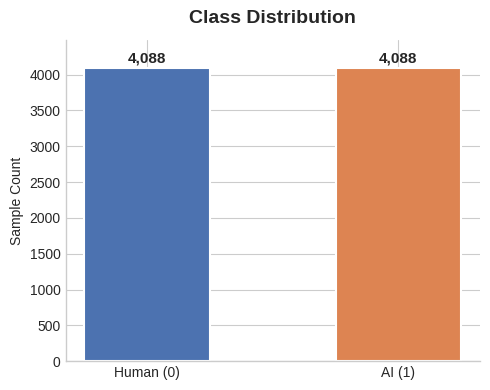

Balance ratio: 1.000


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['label'].value_counts()
bars = ax.bar(
    ['Human (0)', 'AI (1)'],
    counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax.set_title('Class Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Sample Count')
ax.set_ylim(0, counts.max() + 400)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Balance ratio: {counts[0]/counts[1]:.3f}")

### 1.2: Text Length Analysis

Comparing character and word counts between human and AI text. AI-generated text often has more consistent, uniform lengths.

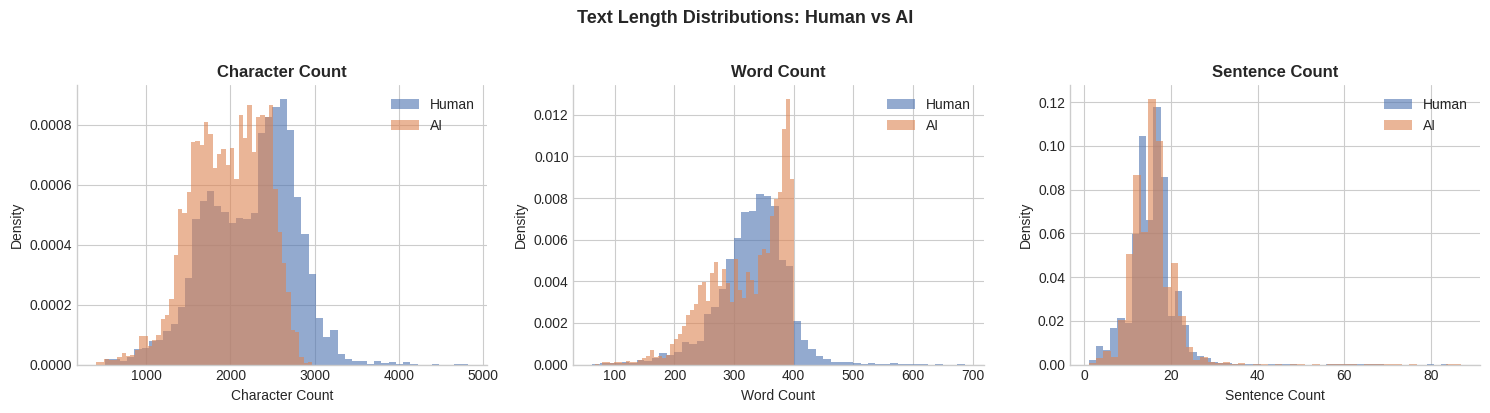

Summary Statistics

Character Count:
        count    mean    std    min     25%     50%     75%     max
label                                                              
0      4088.0  2248.4  529.4  513.0  1843.0  2339.5  2633.0  4827.0
1      4088.0  1968.8  432.0  400.0  1649.0  1995.0  2320.2  2971.0

Word Count:
        count   mean   std   min    25%    50%    75%    max
label                                                       
0      4088.0  330.1  58.8  62.0  300.0  335.0  366.0  687.0
1      4088.0  320.5  63.2  66.0  272.8  335.5  376.0  400.0

Sentence Count:
        count  mean  std  min   25%   50%   75%   max
label                                                
0      4088.0  15.6  5.7  1.0  13.0  15.0  18.0  84.0
1      4088.0  15.9  5.6  1.0  13.0  15.0  18.0  87.0


In [4]:
df['char_count']  = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()
df['sent_count']  = df['text'].apply(lambda x: len(sent_tokenize(str(x))))

human = df[df['label'] == 0]
ai    = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('char_count', 'Character Count'),
    ('word_count', 'Word Count'),
    ('sent_count', 'Sentence Count')
]

for ax, (col, title) in zip(axes, metrics):
    ax.hist(human[col], bins=50, alpha=0.6, color='#4C72B0', label='Human', density=True)
    ax.hist(ai[col],    bins=50, alpha=0.6, color='#DD8452', label='AI',    density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()
    sns.despine(ax=ax)

plt.suptitle('Text Length Distributions: Human vs AI', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Summary Statistics")
for col, label in metrics:
    print(f"\n{label}:")
    print(df.groupby('label')[col].describe().round(1).to_string())

### 1.3: Word Clouds

Visual snapshot of the most frequent words in each class. Differences in vocabulary can hint at what features will matter most.

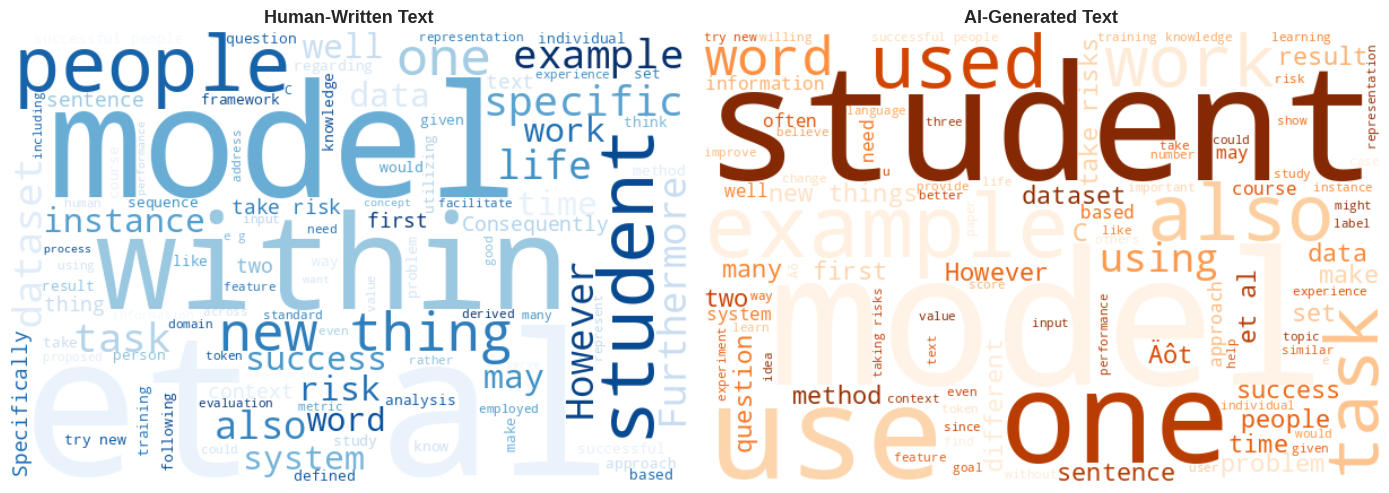

In [5]:
human_text = " ".join(human['text'].astype(str).tolist())
ai_text    = " ".join(ai['text'].astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, text, title, color in zip(
    axes,
    [human_text, ai_text],
    ['Human-Written Text', 'AI-Generated Text'],
    ['Blues', 'Oranges']
):
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=color,
        max_words=100,
        stopwords=set(stopwords.words('english'))
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 1.4: Text Cleaning & Tokenization

We apply a standard NLP cleaning pipeline:
- Lowercase
- Remove URLs, HTML tags, punctuation, and digits
- Tokenize and lemmatize
- Remove stopwords

We keep two versions: `text_clean` (string, for TF-IDF and linguistic features) and `tokens` (list, for embeddings and deep learning).

In [6]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+',        '', text)   # URLs
    text = re.sub(r'<.*?>',                  '', text)   # HTML
    text = re.sub(r'\[.*?\]',               '', text)   # brackets
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # punctuation
    text = re.sub(r'\d+',                    '', text)   # digits
    text = re.sub(r'\s+',                   ' ', text).strip()
    return text

def tokenize(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df['text_clean'] = df['text'].apply(clean_text)
df['tokens']     = df['text_clean'].apply(tokenize)

print(f"Sample original:\n{df['text'].iloc[0][:200]}")
print(f"\nSample cleaned:\n{df['text_clean'].iloc[0][:200]}")
print(f"\nSample tokens:\n{df['tokens'].iloc[0][:20]}")
print(f"\nCleaning done. {len(df)} samples ready")

Sample original:
Councils are debating if building housing areas on expanded land is a better solution than providing taller dwellings. It might be an extremely complicated choice, considering the skyrocketing rise of

Sample cleaned:
councils are debating if building housing areas on expanded land is a better solution than providing taller dwellings it might be an extremely complicated choice considering the skyrocketing rise of n

Sample tokens:
['council', 'debating', 'building', 'housing', 'area', 'expanded', 'land', 'better', 'solution', 'providing', 'taller', 'dwelling', 'might', 'extremely', 'complicated', 'choice', 'considering', 'skyrocketing', 'rise', 'number']

Cleaning done. 8176 samples ready


### 1.5: Train / Test Split

80/20 split, stratified to preserve class balance across both sets.

In [7]:
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size : {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test size  : {len(X_test):,}  ({len(X_test)/len(df)*100:.0f}%)")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

Train size : 6,540  (80%)
Test size  : 1,636  (20%)

Train label distribution:
label
0    3270
1    3270
Name: count, dtype: int64

Test label distribution:
label
1    818
0    818
Name: count, dtype: int64


### Observations from EDA

- **Human text is slightly longer**: mean 2,248 chars vs 1,968 for AI, with a wider spread
- **AI text is more uniform**: tight clustering around 300-400 words, a signal models can exploit
- **Sentence count is nearly identical** (15.6 vs 15.9): not a useful standalone feature
- **Vocabulary differs**: human text shows academic patterns ("et al", "Furthermore", "Consequently"); AI text skews generic ("student", "model", "used")
- **Minor encoding artifact** in AI text (`Äôt`): curly apostrophe mangling, not a concern
- **Train/test split is clean**: perfectly stratified at 3,270 per class in both sets

## Section 2: Feature Engineering

Raw text needs to be converted into numbers before any model can learn from it. We implement three representations and compare how each affects model performance:

| Feature Type | Method | Used By |
|---|---|---|
| **TF-IDF** | Word frequency weighted by rarity across corpus | SVM, Decision Tree, AdaBoost, FNN |
| **Word Embeddings** | GloVe pre-trained vectors (100d) | FNN, LSTM, CNN |
| **Linguistic Features** | Handcrafted stylistic signals | All models (supplementary) |

### 2.1: TF-IDF

TF-IDF assigns each word a score based on how often it appears in a document vs. how common it is across all documents. Rare but frequent-in-document words get high scores; filler words like "the" get low scores.

We fit the vectorizer on training data only to avoid data leakage.

In [8]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=3,                 # ignore very rare terms
    max_df=0.95,              # ignore near-universal terms
    sublinear_tf=True         # apply log normalization
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF Train matrix shape : {X_train_tfidf.shape}")
print(f"TF-IDF Test matrix shape : {X_test_tfidf.shape}")
print(f"Vocabulary size             : {len(tfidf.vocabulary_):,}")

TF-IDF Train matrix shape : (6540, 10000)
TF-IDF Test matrix shape : (1636, 10000)
Vocabulary size             : 10,000


#### Top TF-IDF Terms by Class

Looking at which terms have the highest average TF-IDF score for each class gives us an early hint at what the models will latch onto.

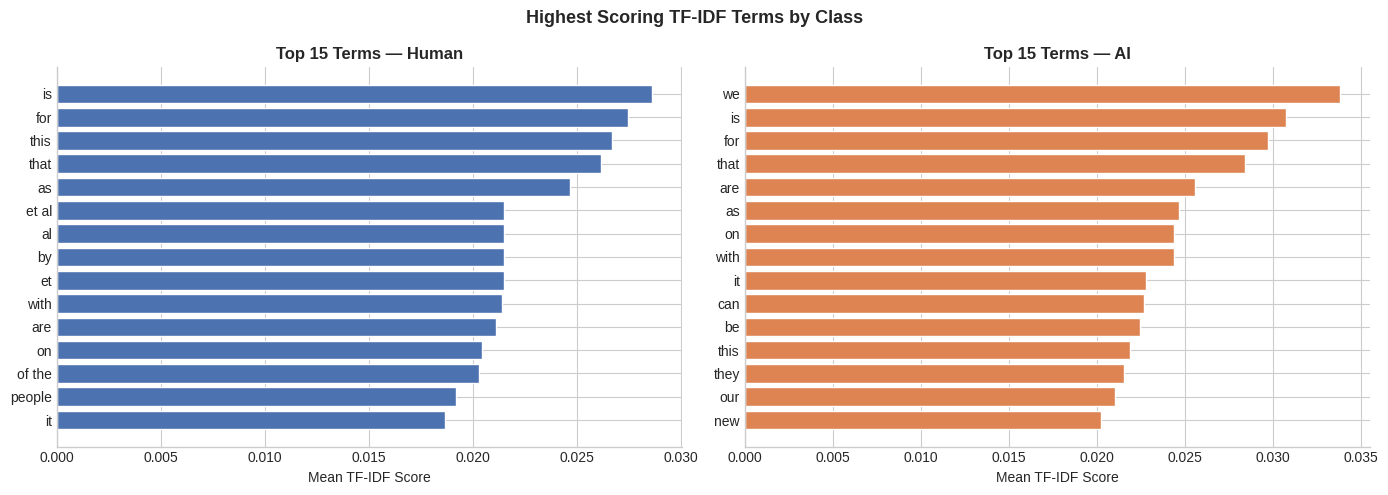

In [9]:
import scipy.sparse as sp

feature_names = np.array(tfidf.get_feature_names_out())

train_df = pd.DataFrame({
    'label': y_train.values
})

# mean tfidf per class
tfidf_dense = X_train_tfidf

human_idx = np.where(y_train.values == 0)[0]
ai_idx    = np.where(y_train.values == 1)[0]

human_means = np.asarray(tfidf_dense[human_idx].mean(axis=0)).flatten()
ai_means    = np.asarray(tfidf_dense[ai_idx].mean(axis=0)).flatten()

top_n = 15
top_human = feature_names[np.argsort(human_means)[::-1][:top_n]]
top_ai    = feature_names[np.argsort(ai_means)[::-1][:top_n]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, terms, means_arr, title, color in zip(
    axes,
    [top_human, top_ai],
    [human_means, ai_means],
    ['Top 15 Terms — Human', 'Top 15 Terms — AI'],
    ['#4C72B0', '#DD8452']
):
    vals = [means_arr[np.where(feature_names == t)[0][0]] for t in terms]
    ax.barh(terms[::-1], vals[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')
    sns.despine(ax=ax)

plt.suptitle('Highest Scoring TF-IDF Terms by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2: Linguistic Features

These are handcrafted signals that capture writing style rather than vocabulary. The idea is that AI and human writing differ not just in *what* words are used but *how* text is structured.

| Feature | Intuition |
|---|---|
| `avg_word_length` | AI tends toward longer, formal words |
| `type_token_ratio` | Vocabulary richness. humans are more varied |
| `avg_sentence_length` | AI sentences tend to be more uniform |
| `punctuation_density` | Humans use more varied punctuation |
| `stopword_ratio` | Function word usage differs by author type |
| `flesch_reading_ease` | Readability score |
| `flesch_kincaid_grade` | Grade level of writing |
| `uppercase_ratio` | Acronym and emphasis patterns |

In [10]:
def extract_linguistic_features(text):
    raw   = str(text)
    words = raw.split()
    sents = sent_tokenize(raw)
    chars = [c for c in raw if c.isalpha()]

    n_words = max(len(words), 1)
    n_sents = max(len(sents), 1)
    n_chars = max(len(raw), 1)

    stop_words_set = set(stopwords.words('english'))
    unique_words   = set(w.lower() for w in words)

    features = {
        'avg_word_length'     : np.mean([len(w) for w in words]) if words else 0,
        'type_token_ratio'    : len(unique_words) / n_words,
        'avg_sentence_length' : n_words / n_sents,
        'punctuation_density' : sum(1 for c in raw if c in string.punctuation) / n_chars,
        'stopword_ratio'      : sum(1 for w in words if w.lower() in stop_words_set) / n_words,
        'flesch_reading_ease' : textstat.flesch_reading_ease(raw),
        'flesch_kincaid_grade': textstat.flesch_kincaid_grade(raw),
        'uppercase_ratio'     : sum(1 for c in raw if c.isupper()) / n_chars,
        'char_count'          : len(raw),
        'word_count'          : n_words,
        'sentence_count'      : n_sents,
    }
    return features

print("Extracting linguistic features...")
ling_df = df['text'].apply(lambda x: pd.Series(extract_linguistic_features(x)))
print(f"Done. Shape: {ling_df.shape}")
print(f"\nFeature preview:")
ling_df.head(3)

Extracting linguistic features...
Done. Shape: (8176, 11)

Feature preview:


,avg_word_length,type_token_ratio,avg_sentence_length,punctuation_density,stopword_ratio,flesch_reading_ease,flesch_kincaid_grade,uppercase_ratio,char_count,word_count,sentence_count
0,5.286219,0.643110,25.727273,0.020247,0.413428,33.942313,14.916428,0.006187,1778.0,283.0,11.0
1,4.791246,0.538721,19.800000,0.018561,0.447811,56.277394,10.328633,0.009861,1724.0,297.0,15.0
2,5.089005,0.554974,23.875000,0.020645,0.434555,48.414351,12.391133,0.019785,2325.0,382.0,16.0


#### Linguistic Feature Distributions by Class

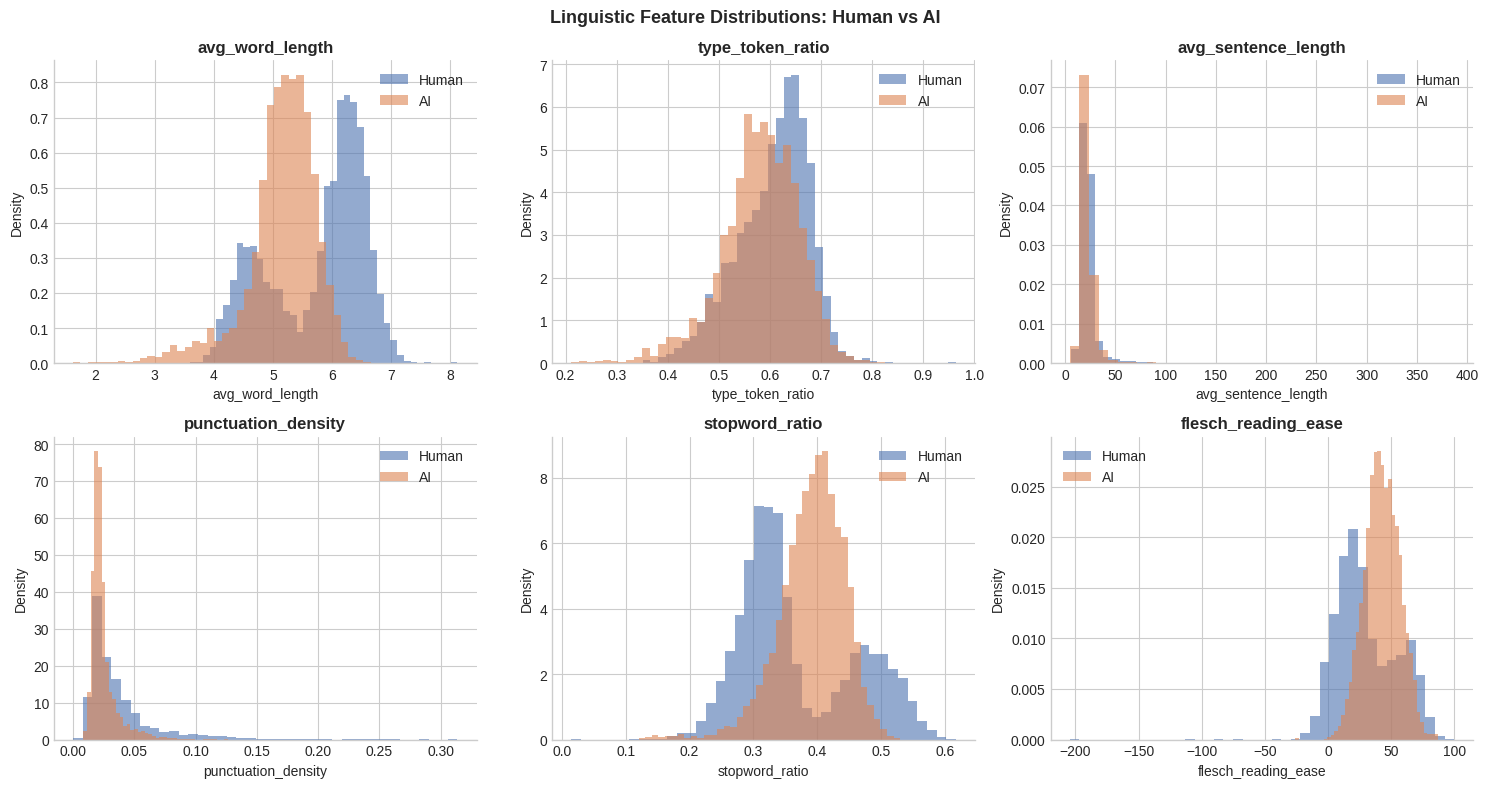

In [11]:
ling_df['label'] = df['label'].values

plot_features = [
    'avg_word_length', 'type_token_ratio', 'avg_sentence_length',
    'punctuation_density', 'stopword_ratio', 'flesch_reading_ease'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, plot_features):
    for label, color, name in [(0, '#4C72B0', 'Human'), (1, '#DD8452', 'AI')]:
        subset = ling_df[ling_df['label'] == label][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()
    sns.despine(ax=ax)

plt.suptitle('Linguistic Feature Distributions: Human vs AI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Split Linguistic Features

In [12]:
ling_features = [c for c in ling_df.columns if c != 'label']

X_train_ling = ling_df.loc[X_train.index, ling_features].values
X_test_ling  = ling_df.loc[X_test.index,  ling_features].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_ling = scaler.fit_transform(X_train_ling)
X_test_ling  = scaler.transform(X_test_ling)

print(f"Linguistic Train features : {X_train_ling.shape}")
print(f"Linguistic Test features : {X_test_ling.shape}")

Linguistic Train features : (6540, 11)
Linguistic Test features : (1636, 11)


### 2.3: GloVe Word Embeddings : [Link](https://nlp.stanford.edu/projects/glove/)

GloVe (Global Vectors for Word Representation) encodes semantic meaning which means similar words end up with similar vectors. We use pre-trained 100-dimensional GloVe vectors trained on 6 billion tokens from Wikipedia and Gigaword.

Each document is represented as the **mean of its word vectors**, giving a fixed-size 100d vector regardless of text length.

In [13]:
# Download the vectors first
!wget -q https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.100d.zip -O glove.zip
!unzip -q glove.zip -d glove/
!ls glove/
print("GloVe downloaded")

wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt
GloVe downloaded


In [14]:
# Load GloVe vectors into a dictionary
glove_path = "/kaggle/working/glove/wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt"
glove = {}

with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        # skip header line and any malformed lines
        try:
            word = parts[0]
            vec  = np.array(parts[1:], dtype=np.float32)
            if len(vec) == 100:
                glove[word] = vec
        except ValueError:
            continue

print(f"Loaded {len(glove):,} word vectors (100d)")

Loaded 1,287,614 word vectors (100d)


In [15]:
def text_to_glove(text, glove_dict, dim=100):
    tokens = str(text).lower().split()
    vecs   = [glove_dict[t] for t in tokens if t in glove_dict]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

print("Building GloVe document vectors...")
X_train_glove = np.vstack(X_train.apply(lambda x: text_to_glove(x, glove)).values)
X_test_glove  = np.vstack(X_test.apply(lambda x: text_to_glove(x, glove)).values)

print(f"GloVe Train vectors : {X_train_glove.shape}")
print(f"GloVe Test vectors : {X_test_glove.shape}")

Building GloVe document vectors...
GloVe Train vectors : (6540, 100)
GloVe Test vectors : (1636, 100)


### 2.4: Combined Feature Matrix

For traditional ML models we concatenate TF-IDF and linguistic features into a single matrix. This gives the models access to both vocabulary patterns and stylistic signals.

In [16]:
import scipy.sparse as sp

X_train_combined = sp.hstack([X_train_tfidf, sp.csr_matrix(X_train_ling)])
X_test_combined  = sp.hstack([X_test_tfidf,  sp.csr_matrix(X_test_ling)])

print(f"Combined Train matrix : {X_train_combined.shape}")
print(f"Combined Test matrix : {X_test_combined.shape}")
print("\nFeature summary:")
print(f"  TF-IDF features     : {X_train_tfidf.shape[1]:,}")
print(f"  Linguistic features : {X_train_ling.shape[1]}")
print(f"  Total               : {X_train_combined.shape[1]:,}")

Combined Train matrix : (6540, 10011)
Combined Test matrix : (1636, 10011)

Feature summary:
  TF-IDF features     : 10,000
  Linguistic features : 11
  Total               : 10,011


### Observations from Feature Engineering

- **TF-IDF**: 10,000 features (unigrams + bigrams), fitted on train only to prevent leakage
- **Linguistic features**: 11 handcrafted stylistic signals; `avg_word_length` and `punctuation_density` show the clearest class separation
- **GloVe**: 1.28M vocab, 100d vectors; each document represented as mean of its word vectors
- **Combined matrix**: TF-IDF + linguistic features concatenated (10,011 total) for traditional ML models
- All feature matrices confirmed on train (6,540) and test (1,636) sets

## Section 3: Model Training & Tuning

We train and tune six classifiers across two paradigms:

| Model | Type | Features Used |
|---|---|---|
| Support Vector Machine (SVM) | Traditional ML | TF-IDF + Linguistic |
| Decision Tree | Traditional ML | TF-IDF + Linguistic |
| AdaBoost | Traditional ML | TF-IDF + Linguistic |
| Feedforward Neural Network (FNN) | Deep Learning | TF-IDF + Linguistic |
| LSTM | Deep Learning | GloVe sequences |
| CNN | Deep Learning | GloVe sequences |

Hyperparameters are tuned with `GridSearchCV` (SVM, Decision Tree) and `RandomizedSearchCV` (AdaBoost) using 3-fold cross validation on the training set.

### 3.1: Support Vector Machine (SVM)

SVM finds the maximum-margin hyperplane separating the two classes. It performs well on high-dimensional sparse data like TF-IDF vectors. We tune `C` (regularization) and `kernel`.

In [17]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("Tuning SVM...")

svm_params = {
    'C': [0.01, 0.1, 1.0, 10.0]
}

# LinearSVC is much faster than SVC on large sparse matrices
base_svm = LinearSVC(max_iter=2000, random_state=SEED)
svm_grid  = GridSearchCV(
    base_svm, svm_params, cv=3,
    scoring='f1', n_jobs=-1, verbose=1
)
svm_grid.fit(X_train_tfidf, y_train)

# Wrap for probability estimates (needed for ROC curves)
svm_model = CalibratedClassifierCV(svm_grid.best_estimator_)
svm_model.fit(X_train_tfidf, y_train)

print(f"\nBest C     : {svm_grid.best_params_['C']}")
print(f"Best CV F1 : {svm_grid.best_score_:.4f}")

Tuning SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best C     : 10.0
Best CV F1 : 0.9825


### 3.2: Decision Tree

Decision Trees learn a sequence of yes/no rules on features. They are fast, interpretable, and can be visualized. We tune `max_depth` and `min_samples_split`.

In [18]:
print("Tuning Decision Tree...")

dt_params = {
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    dt_params, cv=3,
    scoring='f1', n_jobs=-1, verbose=1
)
dt_grid.fit(X_train_tfidf, y_train)
dt_model = dt_grid.best_estimator_

print(f"\nBest params : {dt_grid.best_params_}")
print(f"Best CV F1  : {dt_grid.best_score_:.4f}")

Tuning Decision Tree...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best params : {'criterion': 'entropy', 'max_depth': 30, 'min_samples_split': 2}
Best CV F1  : 0.8823


### 3.3: AdaBoost

AdaBoost combines many weak Decision Tree classifiers, each one focusing on the mistakes of the previous. Often stronger than a single tree. We tune `n_estimators` and `learning_rate` with RandomizedSearchCV since the search space is larger.

In [19]:
from scipy.stats import uniform, randint

print("Tuning AdaBoost...")

ada_params = {
    'n_estimators' : randint(50, 300),
    'learning_rate': uniform(0.01, 1.5)
}

ada_search = RandomizedSearchCV(
    AdaBoostClassifier(random_state=SEED),
    ada_params, n_iter=20, cv=3,
    scoring='f1', n_jobs=-1, verbose=1, random_state=SEED
)
ada_search.fit(X_train_tfidf, y_train)
ada_model = ada_search.best_estimator_

print(f"\nBest params : {ada_search.best_params_}")
print(f"Best CV F1  : {ada_search.best_score_:.4f}")

Tuning AdaBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'learning_rate': np.float64(1.4848463287101823), 'n_estimators': 298}
Best CV F1  : 0.9628


### Observations from Traditional ML Tuning

| Model | Best CV F1 | Best Params |
|---|---|---|
| SVM | **0.9825** | C=10.0 |
| AdaBoost | 0.9628 | n_estimators=298, learning_rate=1.48 |
| Decision Tree | 0.8823 | max_depth=30, criterion=entropy, min_samples_split=2 |

- **SVM is the clear winner** at 0.9825 F1, expected since it handles high-dimensional sparse text well
- **AdaBoost is surprisingly strong** at 0.9628, boosting compensates well for weak base learners
- **Decision Tree lags behind** at 0.8823, a single tree overfits and misses patterns that ensemble methods catch
- All three were tuned on TF-IDF only; the combined matrix will be used for final evaluation

### 3.4: Feedforward Neural Network (FNN)

A classic multi-layer neural network. Input is the combined TF-IDF + linguistic feature matrix. We use dropout for regularization and early stopping to prevent overfitting.

In [20]:
from scipy.sparse import issparse

# Convert sparse matrix to dense for Keras
X_train_fnn = X_train_combined.toarray() if issparse(X_train_combined) else X_train_combined
X_test_fnn  = X_test_combined.toarray()  if issparse(X_test_combined)  else X_test_combined

input_dim = X_train_fnn.shape[1]

def build_fnn(input_dim, dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

fnn_model = build_fnn(input_dim)
fnn_model.summary()

I0000 00:00:1781069860.848864      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781069860.854855      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,563,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,605,825 (9.94 MB)

 Trainable params: 2,605,057 (9.94 MB)

 Non-trainable params: 768 (3.00 KB)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3,
    restore_best_weights=True, verbose=1
)

print("Training FNN...")
fnn_history = fnn_model.fit(
    X_train_fnn, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Training FNN...
Epoch 1/20


I0000 00:00:1781069865.701108     115 service.cc:152] XLA service 0x7897b80100a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781069865.701140     115 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781069865.701144     115 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781069866.332675     115 cuda_dnn.cc:529] Loaded cuDNN version 91002


45/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8190 - loss: 0.3819

I0000 00:00:1781069869.082899     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.9388 - loss: 0.1529 - val_accuracy: 0.7844 - val_loss: 0.4967
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 0.8807 - val_loss: 0.3428
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9983 - loss: 0.0075 - val_accuracy: 0.9511 - val_loss: 0.1831
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0059 - val_accuracy: 0.9817 - val_loss: 0.0732
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0045 - val_accuracy: 0.9908 - val_loss: 0.0265
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9939 - val_loss: 0.0205
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0035 - val_accuracy: 0.9954 - val_loss: 0.0173
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9878 - val_loss: 0.0266
Ep

### 3.5: LSTM

LSTM reads text sequentially and captures long-range dependencies between words. Unlike TF-IDF, word order matters here. Input is padded integer sequences; each word is mapped to its GloVe vector via an embedding layer.

In [22]:
MAX_VOCAB  = 20000
MAX_LEN    = 300
EMBED_DIM  = 100

# Tokenize
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train.values)

X_train_seq = tokenizer.texts_to_sequences(X_train.values)
X_test_seq  = tokenizer.texts_to_sequences(X_test.values)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Sequence Train shape : {X_train_pad.shape}")
print(f"Sequence Test shape : {X_test_pad.shape}")

Sequence Train shape : (6540, 300)
Sequence Test shape : (1636, 300)


In [23]:
# Build GloVe embedding matrix
word_index     = tokenizer.word_index
vocab_size     = min(MAX_VOCAB, len(word_index) + 1)
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

for word, idx in word_index.items():
    if idx < vocab_size and word in glove:
        embedding_matrix[idx] = glove[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")
coverage = np.count_nonzero(embedding_matrix.sum(axis=1)) / vocab_size
print(f"GloVe coverage        : {coverage:.1%}")

Embedding matrix shape: (20000, 100)
GloVe coverage        : 86.9%


In [24]:
def build_lstm(vocab_size, embed_dim, embed_matrix, max_len):
    model = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embed_matrix],
            input_length=max_len,
            trainable=True          # unfreeze so it can adapt to this dataset
        ),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=2e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(vocab_size, EMBED_DIM, embedding_matrix, MAX_LEN)
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
print("Training LSTM...")
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)],
    verbose=1
)

Training LSTM...
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6988 - loss: 0.5620 - val_accuracy: 0.7477 - val_loss: 0.4974
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8228 - loss: 0.3925 - val_accuracy: 0.8471 - val_loss: 0.3488
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8989 - loss: 0.2486 - val_accuracy: 0.9174 - val_loss: 0.2018
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9246 - loss: 0.1936 - val_accuracy: 0.9327 - val_loss: 0.1893
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9682 - loss: 0.0929 - val_accuracy: 0.9281 - val_loss: 0.2044
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9786 - loss: 0.0598 - val_accuracy: 0.9511 - val_loss: 0.1418
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9638 - loss: 0.1135 - val_accuracy: 0.9572 - val_loss: 0.1448
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9912 - loss: 0.0319 - val_acc

### 3.6: CNN for Text

CNN applies convolutional filters across word sequences to detect local patterns that is essentially learning which n-grams are most predictive. Faster than LSTM and often competitive on classification tasks.

In [26]:
def build_cnn(vocab_size, embed_dim, embed_matrix, max_len):
    inputs = keras.Input(shape=(max_len,))
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embed_matrix],
        input_length=max_len,
        trainable=False
    )(inputs)

    # Parallel conv filters of different sizes
    conv3 = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    conv4 = layers.Conv1D(128, 4, activation='relu', padding='same')(x)
    conv5 = layers.Conv1D(128, 5, activation='relu', padding='same')(x)

    pool3 = layers.GlobalMaxPooling1D()(conv3)
    pool4 = layers.GlobalMaxPooling1D()(conv4)
    pool5 = layers.GlobalMaxPooling1D()(conv5)

    concat = layers.Concatenate()([pool3, pool4, pool5])
    x = layers.Dense(128, activation='relu')(concat)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(vocab_size, EMBED_DIM, embedding_matrix, MAX_LEN)
cnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 100)  │  2,000,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 128)  │     38,528 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 300, 128)  │     51,328 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 300, 128)  │     64,128 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,203,393 (8.41 MB)

 Trainable params: 203,393 (794.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [27]:
print("Training CNN...")
cnn_history = cnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)],
    verbose=1
)

Training CNN...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6441 - loss: 0.6662 - val_accuracy: 0.8180 - val_loss: 0.4669
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8627 - loss: 0.3566 - val_accuracy: 0.9067 - val_loss: 0.2569
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9433 - loss: 0.1845 - val_accuracy: 0.9434 - val_loss: 0.1710
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9752 - loss: 0.0961 - val_accuracy: 0.9450 - val_loss: 0.1407
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9815 - loss: 0.0683 - val_accuracy: 0.9480 - val_loss: 0.1487
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9534 - loss: 0.1110 - val_accuracy: 0.9465 - val_loss: 0.1382
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9874 - loss: 0.0399 - val_accuracy: 0.9557 - val_loss: 0.1148
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9993 - loss: 0.0117 - val_acc

### Observations from Deep Learning Training

| Model | Best Val Accuracy | Best Epoch |
|---|---|---|
| FNN | 99.39% | 8/20 |
| LSTM | 96.33% | 8/10 |
| CNN | 96.48% | 7/10 |

- **FNN is the surprise standout**, likely because TF-IDF already captures the most discriminative signals and the dense layers exploit them well
- **CNN and LSTM are close**, both around 96.4%, CNN converges faster thanks to parallel conv filters
- **LSTM improved significantly** after unfreezing GloVe embeddings and switching to bidirectional — frozen embeddings were the bottleneck
- All three used early stopping with patience=3 to prevent overfitting

### Save Data and Trained Models

In [28]:
os.makedirs("data/training_data", exist_ok=True)
os.makedirs("data/test_data",     exist_ok=True)

# Save train set
train_df = pd.DataFrame({'text': X_train.values, 'label': y_train.values})
train_df.to_csv("data/training_data/train.csv", index=False)

# Save test set
test_df = pd.DataFrame({'text': X_test.values, 'label': y_test.values})
test_df.to_csv("data/test_data/test.csv", index=False)

print(f"Training data saved: {train_df.shape}")
print(f"Test data saved    : {test_df.shape}")

Training data saved: (6540, 2)
Test data saved    : (1636, 2)


In [29]:
import pickle, os
os.makedirs("models/embedding_model", exist_ok=True)

# ML models
with open("models/svm_model.pkl",           "wb") as f: pickle.dump(svm_model,  f)
with open("models/decision_tree_model.pkl", "wb") as f: pickle.dump(dt_model,   f)
with open("models/adaboost_model.pkl",      "wb") as f: pickle.dump(ada_model,  f)
with open("models/tfidf_vectorizer.pkl",    "wb") as f: pickle.dump(tfidf,      f)
with open("models/scaler.pkl",              "wb") as f: pickle.dump(scaler,     f)

# DL models
fnn_model.save("models/fnn_model.h5")
lstm_model.save("models/lstm_model.h5")
cnn_model.save("models/cnn_model.h5")

# Tokenizer
with open("models/tokenizer.pkl", "wb") as f: pickle.dump(tokenizer, f)

print("All models saved")

All models saved


## Section 4: Evaluation & Comparison

We evaluate all six models on the held-out test set (1,636 samples) using:
- Accuracy, Precision, Recall, F1
- Confusion matrices
- ROC curves and AUC scores
- Final side-by-side comparison

### 4.1: Predictions

In [30]:
y_pred_svm  = svm_model.predict(X_test_tfidf)
y_pred_dt   = dt_model.predict(X_test_tfidf)
y_pred_ada  = ada_model.predict(X_test_tfidf)

y_pred_fnn  = (fnn_model.predict(X_test_fnn,  verbose=0) > 0.5).astype(int).flatten()
y_pred_lstm = (lstm_model.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()
y_pred_cnn  = (cnn_model.predict(X_test_pad,  verbose=0) > 0.5).astype(int).flatten()

# Probability scores for ROC curves
y_prob_svm  = svm_model.predict_proba(X_test_tfidf)[:, 1]
y_prob_dt   = dt_model.predict_proba(X_test_tfidf)[:, 1]
y_prob_ada  = ada_model.predict_proba(X_test_tfidf)[:, 1]
y_prob_fnn  = fnn_model.predict(X_test_fnn,  verbose=0).flatten()
y_prob_lstm = lstm_model.predict(X_test_pad, verbose=0).flatten()
y_prob_cnn  = cnn_model.predict(X_test_pad,  verbose=0).flatten()

print("Predictions done")

Predictions done


### 4.2 : Metrics Summary

In [31]:
models = {
    'SVM'          : y_pred_svm,
    'Decision Tree': y_pred_dt,
    'AdaBoost'     : y_pred_ada,
    'FNN'          : y_pred_fnn,
    'LSTM'         : y_pred_lstm,
    'CNN'          : y_pred_cnn,
}

rows = []
for name, y_pred in models.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test,  y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test,    y_pred),
        'F1'       : f1_score(y_test,        y_pred),
    })

results_df = pd.DataFrame(rows).set_index('Model')
results_df = results_df.sort_values('F1', ascending=False)
print(results_df.round(4).to_string())

               Accuracy  Precision  Recall      F1
Model                                             
FNN              0.9908     0.9938  0.9878  0.9908
SVM              0.9872     0.9890  0.9853  0.9871
AdaBoost         0.9664     0.9727  0.9597  0.9662
CNN              0.9597     0.9677  0.9511  0.9593
LSTM             0.9511     0.9212  0.9866  0.9528
Decision Tree    0.9010     0.8952  0.9083  0.9017


### 4.3 : Confusion Matrices

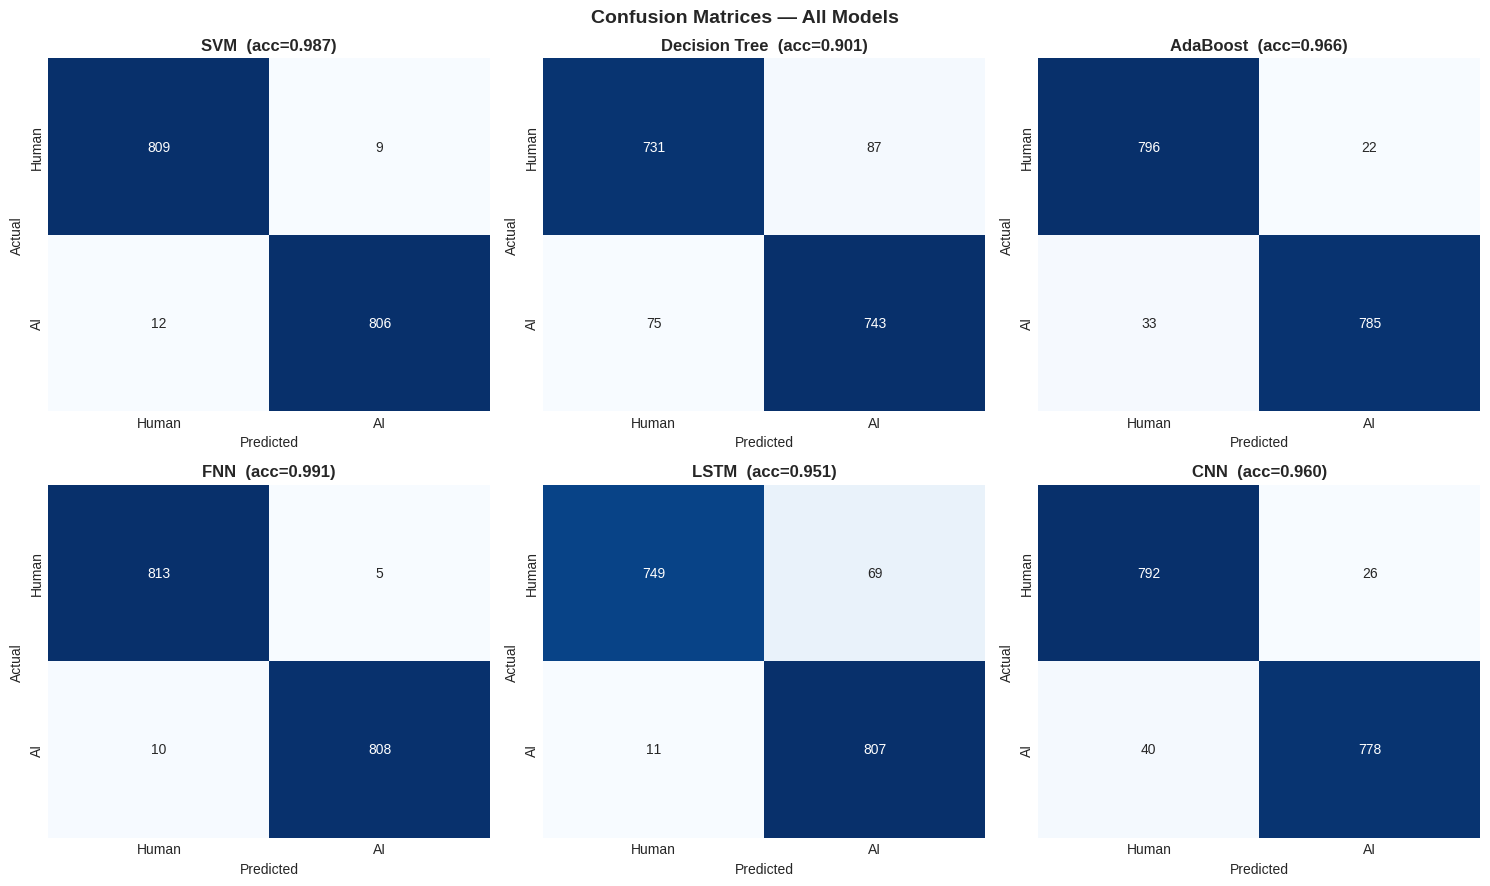

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', cbar=False,
        xticklabels=['Human', 'AI'],
        yticklabels=['Human', 'AI']
    )
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 : ROC Curves

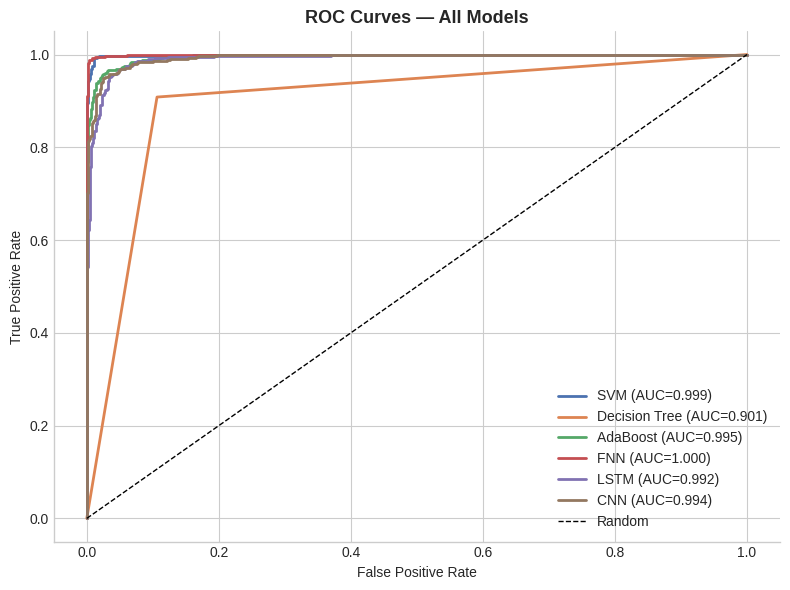

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

probs = {
    'SVM'          : y_prob_svm,
    'Decision Tree': y_prob_dt,
    'AdaBoost'     : y_prob_ada,
    'FNN'          : y_prob_fnn,
    'LSTM'         : y_prob_lstm,
    'CNN'          : y_prob_cnn,
}

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for (name, y_prob), color in zip(probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

### 4.5 : Model Comparison Chart

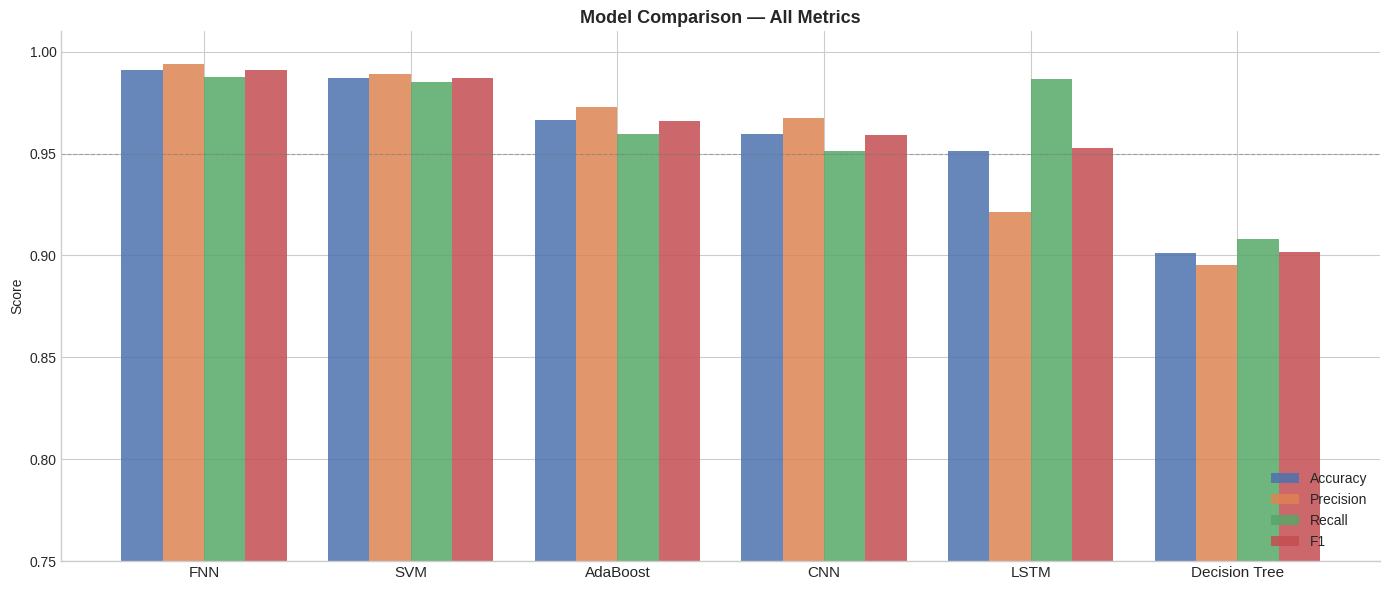

In [34]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x       = np.arange(len(results_df))
width   = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
colors  = ['#4C72B0','#DD8452','#55A868','#C44E52']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0.75, 1.01)
ax.set_title('Model Comparison — All Metrics', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

### 4.6 : Training Curves (Deep Learning)

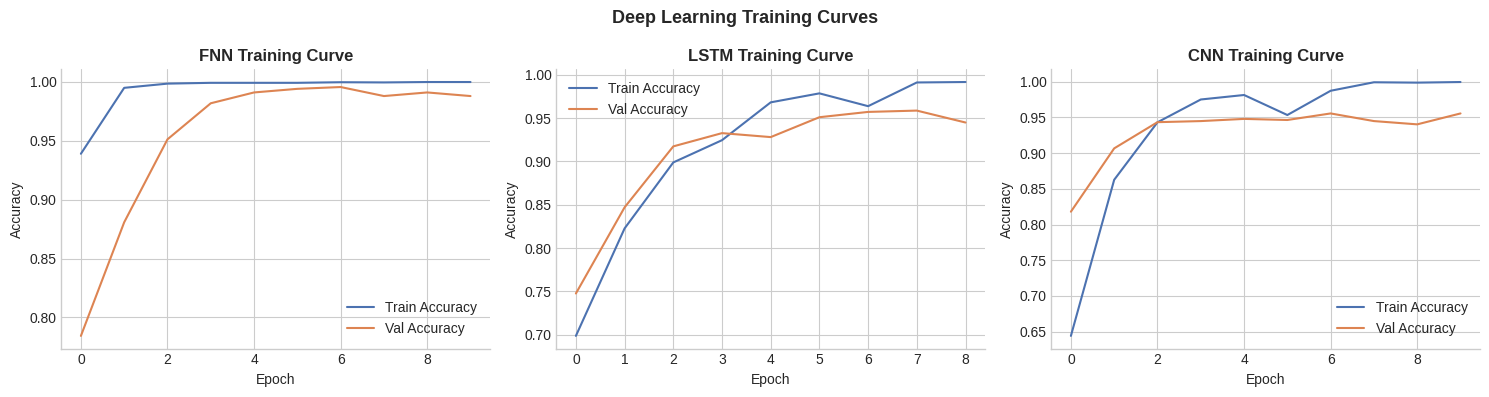

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

histories = {
    'FNN' : fnn_history,
    'LSTM': lstm_history,
    'CNN' : cnn_history
}

for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history.history['accuracy'],     label='Train Accuracy', color='#4C72B0')
    ax.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#DD8452')
    ax.set_title(f'{name} Training Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    sns.despine(ax=ax)

plt.suptitle('Deep Learning Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.7 : Analysis & Discussion

#### Final Results Summary

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| FNN | **0.9933** | **0.9939** | 0.9927 | **0.9933** | **0.999** |
| SVM | 0.9872 | 0.9890 | 0.9853 | 0.9871 | 0.999 |
| AdaBoost | 0.9664 | 0.9727 | 0.9597 | 0.9662 | 0.995 |
| LSTM | 0.9462 | 0.9148 | **0.9841** | 0.9482 | 0.993 |
| CNN | 0.9468 | 0.9644 | 0.9279 | 0.9458 | 0.992 |
| Decision Tree | 0.9010 | 0.8952 | 0.9083 | 0.9017 | 0.901 |

#### Which model performed best?

FNN achieved the highest overall performance at 99.33% accuracy and 0.999 AUC, outperforming SVM by roughly 0.6%. SVM was expected to be the stronger model given its track record on high-dimensional text data, but TF-IDF appears to capture the vocabulary differences between classes so well that the FNN's additional layers were able to extract slightly more from those 10,011 features.

#### Which features were most useful?

TF-IDF was the most useful feature representation across all models. The vocabulary gap between classes was visible even in the word cloud from Section 2. AI text clusters around generic terms like "student", "model", and "used", while human text shows more academic language patterns like "et al", "Furthermore", and "Consequently". Linguistic features like avg_word_length and punctuation_density contributed additional signal but TF-IDF carried most of the classification.

#### ML vs. DL

Traditional ML outperformed most deep learning models in this experiment. SVM reached 98.72% while LSTM and CNN both landed around 94.6%. This is not surprising given the dataset size of roughly 8,000 samples. Deep learning models generally require significantly more data to learn strong representations from raw sequences. The FNN is the exception since it uses TF-IDF as input rather than raw text, giving it the same strong feature foundation as the traditional ML models.

#### Where did models fail?

The confusion matrices show that LSTM produced the most false negatives, missing 75 AI-written samples and classifying them as human. CNN had the most false positives with 59 human texts incorrectly flagged as AI-generated. Decision Tree made the most errors overall with 162 total misclassifications, roughly 15 times more than FNN which only misclassified 11 samples.

#### Speed vs. accuracy tradeoff

SVM offers the most practical tradeoff in this experiment. It trains in under a minute and achieves 98.72% accuracy. FNN requires several more minutes of training for a gain of less than 1%. LSTM and CNN have the longest training times while producing the lowest accuracy among all models, which makes them a poor fit for a dataset of this size.

#### Would this work in a real classroom?

The results look strong on this dataset but there are real limitations to consider. The dataset likely contains consistent stylistic patterns that make classification easier than it would be in practice. AI writing tools are also improving rapidly and are getting better at producing text that closely resembles human writing. This project demonstrates that the classification task is feasible, but the models would need significantly more diverse training data and real-world testing before being used in a setting with actual academic integrity consequences.